<a href="https://colab.research.google.com/github/Rishapriakanth/Project/blob/main/brain_tumor_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
for dirname, _, filenames in os.walk('/content/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


In [ ]:
import sys
sys.executable

'/usr/bin/python3'

In [ ]:
import keras
from keras.models import Sequential
from keras.layers import Conv2D,Flatten,Dense,MaxPooling2D,Dropout
from sklearn.metrics import accuracy_score


In [ ]:
import ipywidgets as widgets
import io
from PIL import Image
import tqdm
from sklearn.model_selection import train_test_split
import cv2
from sklearn.utils import shuffle
import tensorflow as tf


In [ ]:
base_dir = (r'/content/drive/MyDrive/ColabNotebooks/datasets')

In [ ]:
data_dir = (r'/content/drive/MyDrive/ColabNotebooks/datasets/DS/Testing/glioma_tumor')

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd

X_train = []
Y_train = []
image_size = 150
labels = ['glioma_tumor','meningioma_tumor','no_tumor','pituitary_tumor']
paths = []
label  = []

for i in labels:
    folderPath = os.path.join('/content/drive/MyDrive/ColabNotebooks/datasets/DS/Training',i)
    paths.append(folderPath)
    label.append(i)
    for j in os.listdir(folderPath):
        img = cv2.imread(os.path.join(folderPath,j))
        img = cv2.resize(img,(image_size,image_size))
        X_train.append(img)
        Y_train.append(i)

for i in labels:
    folderPath = os.path.join('/content/drive/MyDrive/ColabNotebooks/datasets/DS/Testing',i)
    for j in os.listdir(folderPath):
        img = cv2.imread(os.path.join(folderPath,j))
        img = cv2.resize(img,(image_size,image_size))
        X_train.append(img)
        Y_train.append(i)

X_train = np.array(X_train)
Y_train = np.array(Y_train)

data ={
    'Path':paths,
    'label':label
}
df = pd.DataFrame(data)

df.to_csv('dataset.csv',index=False)
display(df)


,Path,label
0,/content/drive/MyDrive/ColabNotebooks/datasets...,glioma_tumor
1,/content/drive/MyDrive/ColabNotebooks/datasets...,meningioma_tumor
2,/content/drive/MyDrive/ColabNotebooks/datasets...,no_tumor
3,/content/drive/MyDrive/ColabNotebooks/datasets...,pituitary_tumor


from matplotlib import pyplot as plt
import seaborn as sns
df.groupby('Path').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
df.groupby('label').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['label'].value_counts()
    for x_label, grp in df.groupby('Path')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('Path')
_ = plt.ylabel('label')

In [ ]:
from sklearn.utils import shuffle
X_train,Y_train = shuffle(X_train,Y_train,random_state=101)
X_train.shape



(3264, 150, 150, 3)

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X_train,Y_train,test_size=0.1,random_state=101)


In [ ]:
import tensorflow as tf

y_train_new = []
for i in y_train:
    y_train_new.append(labels.index(i))
y_train=y_train_new
y_train = tf.keras.utils.to_categorical(y_train)

y_test_new = []
for i in y_test:
    y_test_new.append(labels.index(i))
y_test=y_test_new
y_test = tf.keras.utils.to_categorical(y_test)


In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D,Flatten,Dense,MaxPooling2D,Dropout
from sklearn.metrics import accuracy_score
model = Sequential()
model.add(Conv2D(32,(3,3),activation = 'relu',input_shape=(150,150,3)))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(Dropout(0.3))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(Conv2D(256,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(512,activation = 'relu'))
model.add(Dense(512,activation = 'relu'))
model.add(Dropout(0.3))
model.add(Dense(4,activation='softmax'))


In [ ]:
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 148, 148, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 146, 146, 64)      18496     
                                                                 
 max_pooling2d (MaxPooling2  (None, 73, 73, 64)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 73, 73, 64)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 71, 71, 64)        36928     
                                                                 
 conv2d_3 (Conv2D)           (None, 69, 69, 64)        36928     
                                                        

In [ ]:
model.compile(loss='categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
model.save('braintumor.h5')


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Epoch 1/20
83/83 [==============================] - 613s 7s/step - loss: 2.1374 - accuracy: 0.2902 - val_loss: 1.3662 - val_accuracy: 0.2891
Epoch 2/20
83/83 [==============================] - 604s 7s/step - loss: 1.2546 - accuracy: 0.4022 - val_loss: 1.0476 - val_accuracy: 0.5476
Epoch 3/20
83/83 [==============================] - 610s 7s/step - loss: 0.9988 - accuracy: 0.5815 - val_loss: 0.8857 - val_accuracy: 0.6224
Epoch 4/20
83/83 [==============================] - 607s 7s/step - loss: 0.8424 - accuracy: 0.6322 - val_loss: 0.8061 - val_accuracy: 0.6463
Epoch 5/20
83/83 [==============================] - 613s 7s/step - loss: 0.7290 - accuracy: 0.6977 - val_loss: 0.7349 - val_accuracy: 0.6429
Epoch 6/20
83/83 [==============================] - 587s 7s/step - loss: 0.6442 - accuracy: 0.7295 - val_loss: 0.6405 - val_accuracy: 0.7075
Epoch 7/20
83/83 [==============================] - 596s 7s/step - loss: 0.5686 - accuracy: 0.7722 - val_loss: 0.5501 - val_accuracy: 0.7551
Epoch 8/20
83

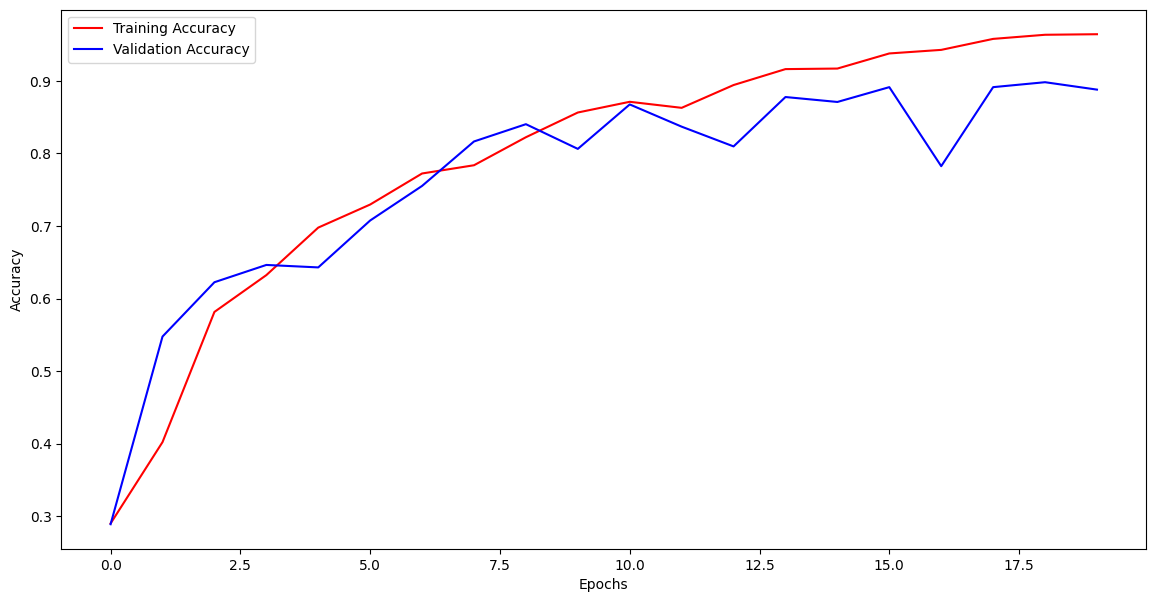

In [ ]:
history = model.fit(X_train,y_train,epochs=20,validation_split=0.1)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(len(acc))
fig = plt.figure(figsize=(14,7))
plt.plot(epochs,acc,'r',label="Training Accuracy")
plt.plot(epochs,val_acc,'b',label="Validation Accuracy")
plt.legend(loc='upper left')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()


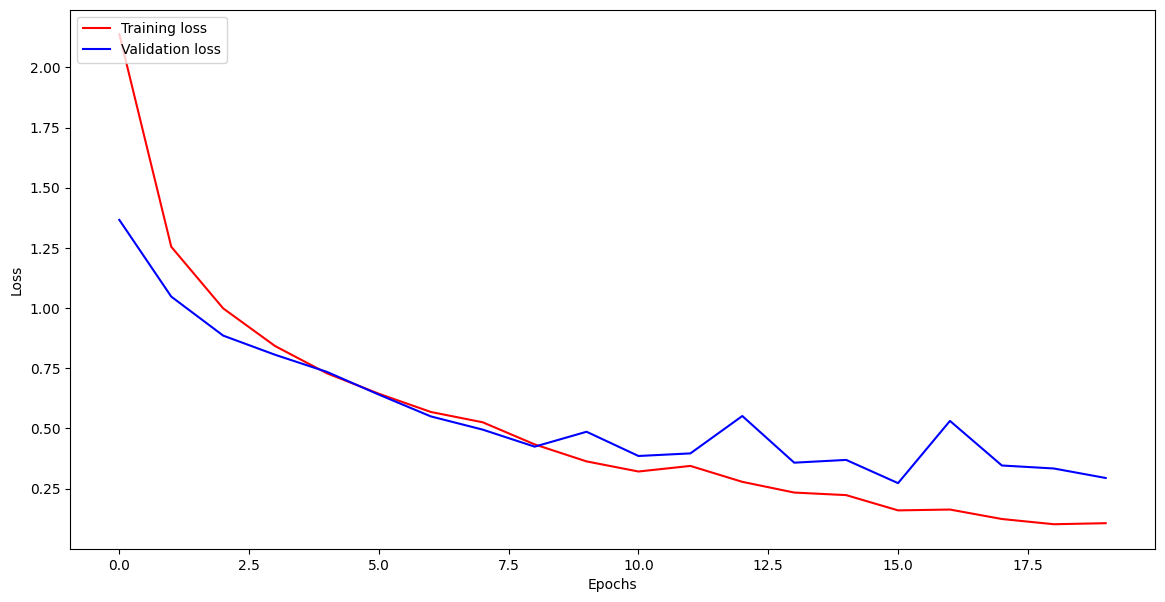

In [ ]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(loss))
fig = plt.figure(figsize=(14,7))
plt.plot(epochs,loss,'r',label="Training loss")
plt.plot(epochs,val_loss,'b',label="Validation loss")
plt.legend(loc='upper left')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()


In [ ]:
import random
import numpy as np

class Node:
    def __init__(self, id):
        self.id = id
        self.clock = random.uniform(0, 10)  # Initial random clock value

    def update_clock(self, new_time):
        self.clock = new_time

def fault_tolerant_average(nodes, fault_count):
    # Simulate faults by randomly selecting nodes to fail
    faulty_nodes = random.sample(nodes, fault_count)
    print(f"Faulty nodes: {[node.id for node in faulty_nodes]}")

    # Collect time values from non-faulty nodes
    valid_times = [node.clock for node in nodes if node not in faulty_nodes]

    if not valid_times:
        print("All nodes are faulty!")
        return None

    # Calculate the average time from valid nodes
    average_time = np.mean(valid_times)
    print(f"Average time from non-faulty nodes: {average_time:.2f}")

    # Update clocks of non-faulty nodes
    for node in nodes:
        if node not in faulty_nodes:
            node.update_clock(average_time)

    # Display updated clock values
    for node in nodes:
        print(f"Node {node.id} updated clock: {node.clock:.2f}")

# Simulation parameters
num_nodes = 10
fault_count = 2  # Number of nodes that may fail

# Create nodes
nodes = [Node(i) for i in range(num_nodes)]

# Run the fault-tolerant average algorithm
fault_tolerant_average(nodes, fault_count)


Faulty nodes: [6, 2]
Average time from non-faulty nodes: 5.68
Node 0 updated clock: 5.68
Node 1 updated clock: 5.68
Node 2 updated clock: 1.78
Node 3 updated clock: 5.68
Node 4 updated clock: 5.68
Node 5 updated clock: 5.68
Node 6 updated clock: 4.38
Node 7 updated clock: 5.68
Node 8 updated clock: 5.68
Node 9 updated clock: 5.68


In [ ]:
pip install diagrams


In [ ]:
!pip install diagrams --upgrade

In [ ]:
from diagrams import Diagram, Cluster
from diagrams.programming.flowchart import Start, Condition, Operation, End  # For newer diagrams versions

# OR, if you have an older version of diagrams:
# from diagrams import Diagram, Cluster
# from diagrams.aws.general import Start, End  # Use general shapes
# from diagrams.gcp.analytics import DataPreprocessing


# Your flowchart code (using the newer flowchart shapes if you upgraded)
with Diagram("KOA Diagnosis Flowchart", show=False) as diag:
    labeled_data = Start("Labeled Dataset")
    unlabeled_data = Start("Unlabeled Dataset")

    with Cluster("Data Preprocessing"):
        preprocessing = Operation("Data Preprocessing")
        resizing = Operation("Resizing")
        normalization = Operation("Normalization")
        augmentation = Operation("Augmentation")

    with Cluster("Pseudo-Labeling"):
        pseudo_labeling = Operation("Pseudo-Labeling")
        high_confidence = Condition("Predictions with confidence > 0.8")
        low_confidence = Condition("Predictions with confidence < 0.8")
        labeled_pseudo = Operation("Labeled as pseudo-labels")
        ignored = Operation("Ignored")

    with Cluster("ACHL Model Training"):
        achl_training = Operation("ACHL Model training")
        contrastive_learning = Operation("Contrastive Learning Module:\nContrastive loss between embeddings")
        classification_head = Operation("Classification Head:\nOutputs KOA class labels")

    model_evaluation = Operation("Model Evaluation")
    metrics_output = Operation("Metrics Output:\nAccuracy, Precision, Recall, F1-score")

    prediction_layer = Operation("Prediction Layer")
    koa_diagnosis = End("KOA Diagnosis Output:\nNormal, Doubtful, Mild, Moderate, Severe")


    labeled_data >> preprocessing
    unlabeled_data >> pseudo_labeling

    preprocessing >> resizing
    preprocessing >> normalization
    preprocessing >> augmentation

    pseudo_labeling >> high_confidence
    pseudo_labeling >> low_confidence

    high_confidence >> labeled_pseudo
    low_confidence >> ignored

    resizing >> achl_training
    normalization >> achl_training
    augmentation >> achl_training
    labeled_pseudo >> achl_training

    achl_training >> contrastive_learning
    achl_training >> classification_head

    contrastive_learning >> model_evaluation
    classification_head >> model_evaluation

    model_evaluation >> metrics_output
    metrics_output >> prediction_layer
    prediction_layer >> koa_diagnosis

ImportError: cannot import name 'Start' from 'diagrams.programming.flowchart' (/usr/local/lib/python3.11/dist-packages/diagrams/programming/flowchart.py)